## Data Cleaning

- **Handle outliers** in numerical variables using appropriate techniques, mainly treating them with domain knowlege (Winsorization) or capping them at Q1 - 3IQR | Q3 + 3IQR.  
- Use **histograms** to visualize distributions **before and after** cleaning.


## Imports / settings

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)

## Read dataset
Previously cleaned:
- missing values standardized
- string normalized / typo correction

In [2]:
data = pd.read_csv("../data/interim/02. FRAIL_clean_text.csv")
print(data.shape)
data.head()

(6855, 85)


,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,...,MMSE_LINGUAGEM_D_LEITURA,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100
0,19,1,Joane,2021-11-16,1941-08-20,80.0,F,Água,2.0,153.0,...,1.0,1.0,0.0,16.0,1.0,1.0,1.0,1.0,2.0,80.0
1,19,3,Joane,2022-11-16,1941-08-20,81.0,F,Água,2.0,152.0,...,1.0,1.0,0.0,20.0,2.0,2.0,2.0,2.0,1.0,80.0
2,19,4,Joane,2023-06-20,1941-08-20,81.0,F,Água,2.0,153.0,...,0.0,1.0,0.0,16.0,1.0,1.0,1.0,2.0,1.0,90.0
3,37,1,Joane,2021-11-16,1948-11-20,72.0,F,Água,2.0,149.0,...,1.0,1.0,0.0,20.0,1.0,1.0,1.0,1.0,2.0,100.0
4,37,2,Joane,2022-06-29,1948-11-20,73.0,F,Água,2.0,150.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0


## Small analysis

In [3]:
data.dtypes

ID_Aluno                                               int64
Momento                                                int64
Local_de_Avaliacao                                    object
Data_avaliacao                                        object
Data_nascimento                                       object
Age                                                  float64
Genero                                                object
Modalidade                                            object
Freq_semanal                                         float64
ANTROPOMETRIA_Estatura_cm                            float64
ANTROPOMETRIA_Peso_Kg                                float64
Escolaridade                                          object
Quedas_ultimos_12meses                                object
Quedas_12meses_Quantas                               float64
Quedas_12meses_Situacao                               object
Quedas_12meses_Lesao_Sim_Nao                          object
Quedas_12meses_Lesao_Tip

In [4]:
data.columns

Index(['ID_Aluno', 'Momento', 'Local_de_Avaliacao', 'Data_avaliacao',
       'Data_nascimento', 'Age', 'Genero', 'Modalidade', 'Freq_semanal',
       'ANTROPOMETRIA_Estatura_cm', 'ANTROPOMETRIA_Peso_Kg', 'Escolaridade',
       'Quedas_ultimos_12meses', 'Quedas_12meses_Quantas',
       'Quedas_12meses_Situacao', 'Quedas_12meses_Lesao_Sim_Nao',
       'Quedas_12meses_Lesao_Tipo', 'Quedas_12meses_Lesao_Local',
       'Quedas_12meses_Assistencia_hospitalar_Sim_Não',
       'Quedas_12meses_Hospitalizado_Sim_Não',
       'Quedas_12meses_Hospitalizado_Dias', 'Quedas_12meses_Medo_cair_Sim_Não',
       'ATIVIDADE_FISICA_Geral_Sim_Não',
       'ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana',
       'ATIVIDADE_FISICA_Caminhada_Duracao_min_dia',
       'ATIVIDADE_FISICA_Caminhada_Intensidade',
       'ATIVIDADE_FISICA_Outras_AF_Qual',
       'ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana',
       'ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia',
       'ATIVIDADE_FISICA_Outras_AF_Intensidade',

In [5]:
numeric_data = data[['ID_Aluno', 'Momento', 'Age', 'Freq_semanal', 'ANTROPOMETRIA_Estatura_cm', 'ANTROPOMETRIA_Peso_Kg', 'Quedas_12meses_Quantas',
                    'Quedas_12meses_Hospitalizado_Dias', 'ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana', 'ATIVIDADE_FISICA_Caminhada_Duracao_min_dia',
                    'ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana', 'ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia', 'ANTROPOMETRIA_Massa_gorda',
                    'ANTROPOMETRIA_Massa_magra_Kg', 'ANTROPOMETRIA_Gordura_visceral', 'HANDGRIP_DIREITA_tentaiva1',
                    'HANDGRIP_DIREITA_tentativa2', 'HANDGRIP_DIREITA_tentativa_3',
                    'HANDGRIP_ESQUERDA_tentativa1', 'HANDGRIP_ESQUERDA_tentativa2',
                    'HANDGRIP_ESQUERDA_tentativa3', 'TIMED_UP_AND_GO_Simples_tentativa1',
                    'TIMED_UP_AND_GO_Simples_tentativa2', 'Best_TIMED_UP_AND_GO_Simples', 'TIMED_UP_AND_GO_Dupla_tarefa_tentativa1',
       'TIMED_UP_AND_GO_Dupla_tarefa_tentativa2',
       'Best_TIMED_UP_AND_GO_Dupla_tarefa', 'SIT_TO_STAND_Repetiçoes','@6_MIN_ANDAR_N_voltas_completas',
       '@6_MIN_ANDAR_Resultado_teste_Metros',
       '@6_MIN_ANDAR_Distancia_TOTAL_metros', '@6_MIN_ANDAR_Parou_Quantas_vezes', 'MMSE_ORIENTACAO_TEMPORAL',
       'MMSE_ORIENTACAO_ESPACIAL', 'MMSE_RETENCAO', 'MMSE_ATENCAO_CALCULO',
       'MMSE_EVOCACAO_1', 'MMSE_LINGUAGEM_A_NOMEACAO',
       'MMSE_LINGUAGEM_B_REPETICAO', 'MMSE_LINGUAGEM_C_COMANDO',
       'MMSE_LINGUAGEM_D_LEITURA', 'MMSE_LINGUAGEM_E_FRASE_ESCRITA',
       'MMSE_COPIA_DESENHO_1', 'MMSE_Total', 'EQ5D5L_MOBILIDADE',
       'EQ5D5L_CUIDADOS_PESSOAIS', 'EQ5D5L_ATIVIDADES_HABITUAIS',
       'EQ5D5L_DOR_MAL_ESTAR', 'EQ5D5L_ANSIEDADE_DEPRESSAO',
       'EQ5D5L_A_sua_saude_hoje_0_100']]

numeric_data.dtypes

ID_Aluno                                               int64
Momento                                                int64
Age                                                  float64
Freq_semanal                                         float64
ANTROPOMETRIA_Estatura_cm                            float64
ANTROPOMETRIA_Peso_Kg                                float64
Quedas_12meses_Quantas                               float64
Quedas_12meses_Hospitalizado_Dias                    float64
ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana    float64
ATIVIDADE_FISICA_Caminhada_Duracao_min_dia           float64
ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana    float64
ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia           float64
ANTROPOMETRIA_Massa_gorda                            float64
ANTROPOMETRIA_Massa_magra_Kg                         float64
ANTROPOMETRIA_Gordura_visceral                       float64
HANDGRIP_DIREITA_tentaiva1                           float64
HANDGRIP_DIREITA_tentati

We can analyze an isolated variable

Statistic resume: EQ5D5L_A_sua_saude_hoje_0_100
count    6673.000000
mean       76.438498
std        17.323660
min         0.000000
25%        65.000000
50%        80.000000
75%        90.000000
max       100.000000
Name: EQ5D5L_A_sua_saude_hoje_0_100, dtype: float64

 unique values 53
Min: 0.0
MAx: 100.0

Smallest values
      ID_Aluno  EQ5D5L_A_sua_saude_hoje_0_100 Genero   Age
3035     16562                            0.0      F  74.0
2828     16366                            0.0      F  61.0
3973     19790                            0.0      F  63.0
6444     28969                            1.0      F  67.0
1561      5049                            2.5      F  75.0
4752     24898                           10.0      F  85.0
76        2160                           10.0      M  74.0
53        1005                           10.0      F  74.0
1635      5126                           10.0      F  67.0
2446     10931                           10.0      F  76.0

Highest values
      ID_Al

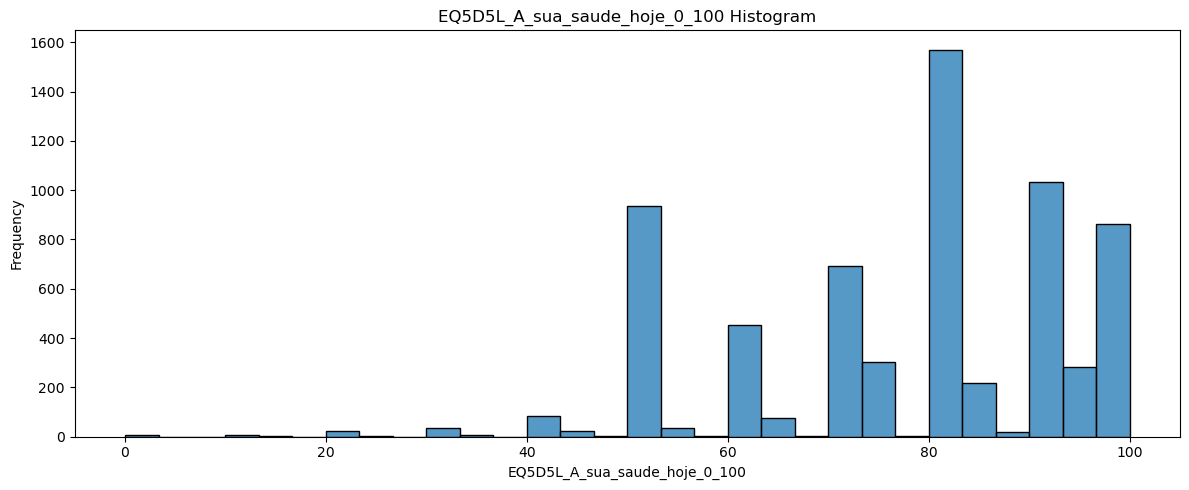

In [6]:
col = 'EQ5D5L_A_sua_saude_hoje_0_100' 

print(f"Statistic resume: {col}")
print(data[col].describe())  # count, mean, std, min, max, quartis
print("\n unique values", data[col].nunique())

print("Min:", data[col].min())
print("MAx:", data[col].max())

cols_to_show = ['ID_Aluno', col, 'Genero', 'Age']

sorted_data = data[cols_to_show].dropna(subset=[col]).sort_values(by=col)

print(f"\nSmallest values")
print(sorted_data.head(10))

print(f"\nHighest values")
print(sorted_data.tail(10))

plt.figure(figsize=(12,5))

# Histogram
sns.histplot(data[col].dropna(), bins=30, kde=False)
plt.title(f"{col} Histogram")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Numeric data cleaning

## Age

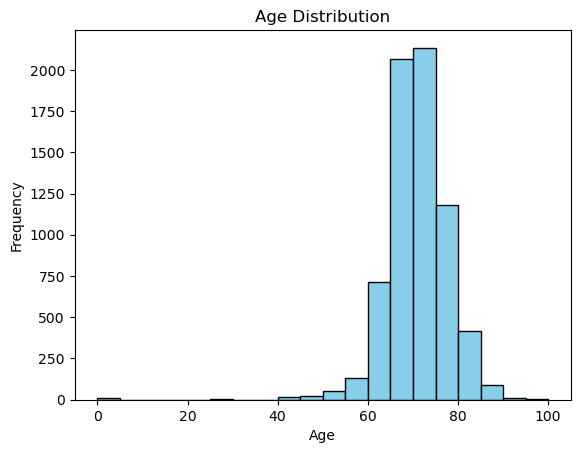

In [7]:
plt.hist(data["Age"].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [8]:
# Group by person and calculate max and min
grouped = data.groupby('ID_Aluno')['Age'].agg(['min', 'max'])

# Calculate shift
grouped['shift'] = grouped['max'] - grouped['min']

# Filter for people with shift > 10
people_with_shift_Age = grouped[grouped['shift'] > 2].sort_values(by='shift', ascending=False)
people_with_shift_Age

,min,max,shift
ID_Aluno,,,
19133,0.0,100.0,100.0
5414,0.0,99.0,99.0
4948,60.0,68.0,8.0
4400,74.0,81.0,7.0
4276,71.0,74.0,3.0


## People with great shift in weight and height between moments

In [9]:
# Group by person and calculate max and min
grouped = data.groupby('ID_Aluno')['ANTROPOMETRIA_Peso_Kg'].agg(['min', 'max'])

# Calculate shift
grouped['shift'] = grouped['max'] - grouped['min']

# Filter for people with shift > 10
people_with_shift = grouped[grouped['shift'] > 15].sort_values(by='shift', ascending=False)

In [10]:
people_with_shift

,min,max,shift
ID_Aluno,,,
22595,87.0,885.5,798.5
4530,79.4,778.0,698.6
19683,8.4,82.3,73.9
5600,22.6,94.6,72.0
25125,7.2,73.0,65.8
20837,7.7,72.4,64.7
799,27.8,90.5,62.7
5255,19.0,81.1,62.1
4641,19.4,79.6,60.2


In [11]:
data[data["ID_Aluno"] == 24957]["ANTROPOMETRIA_Peso_Kg"]

4856    60.1
4857    98.1
4858    58.8
4859    56.3
Name: ANTROPOMETRIA_Peso_Kg, dtype: float64

In [12]:
# Group by person and calculate max and min
grouped = data.groupby('ID_Aluno')['ANTROPOMETRIA_Estatura_cm'].agg(['min', 'max'])

# Calculate shift
grouped['shift'] = grouped['max'] - grouped['min']

# Filter for people with shift > 10
people_with_shift = grouped[grouped['shift'] > 10].sort_values(by='shift', ascending=False)
print(people_with_shift.shape)
people_with_shift

(19, 3)


,min,max,shift
ID_Aluno,,,
25008,15.8,157.0,141.2
19742,144.0,200.0,56.0
12274,156.0,187.0,31.0
3957,125.5,155.0,29.5
25006,152.0,181.0,29.0
25269,148.0,174.5,26.5
25590,138.0,160.0,22.0
23658,154.5,174.0,19.5
20990,139.0,155.0,16.0


In [13]:
print(data[data["ID_Aluno"] == 24918]["ANTROPOMETRIA_Estatura_cm"])

4765    164.8
4766    154.0
4767    154.5
Name: ANTROPOMETRIA_Estatura_cm, dtype: float64


## Histograms of variables
We can visualize the distributions with outliers

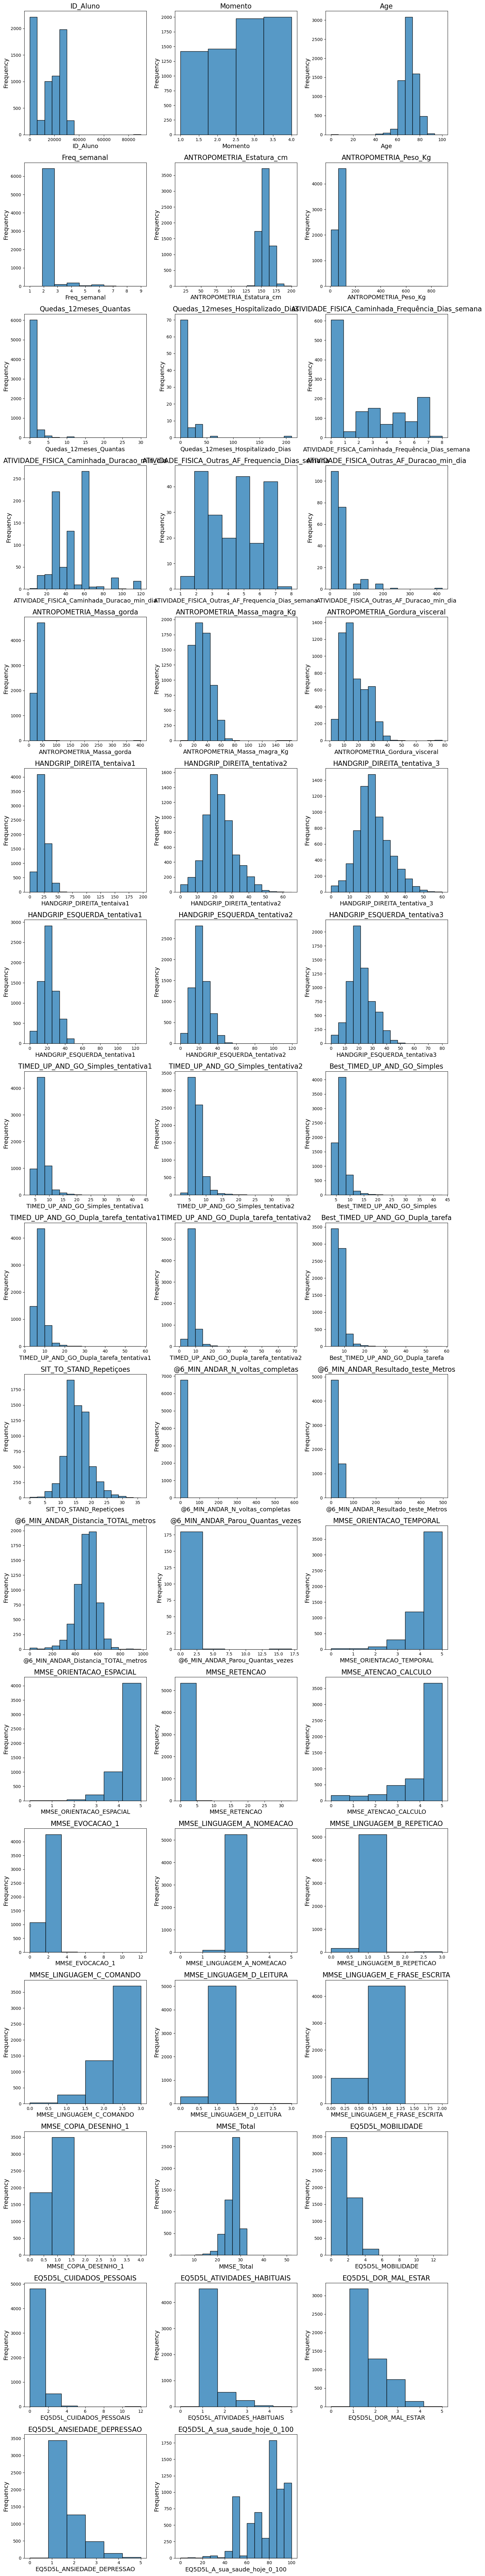

In [14]:
numerical_vars = data.select_dtypes(include='number').columns.tolist()
numerical_vars = [var for var in numerical_vars if len(data[var].unique()) > 2]
ncols = 3

# Calculate the number of rows needed based on the number of columns
nrows = -(-len(numerical_vars) // ncols)  # Ceiling division to get the number of rows

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))

# Flatten the 2D array of subplots to a 1D array for easier indexing
axes = axes.flatten()

# Loop through variables and create histograms
for i, variable in enumerate(numerical_vars):
    ax = axes[i]
    bins = min([len(data[variable].value_counts()),15])
    sns.histplot(data = data, x = variable, ax=ax, bins = bins)
    ax.set_title(variable, fontsize=16) 
    ax.set_xlabel(variable, fontsize=14) 
    ax.set_ylabel('Frequency', fontsize=14)

# Remove empty subplots
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Data cleaning numerical vars
- Replace invalid ages with valid from same ID or remove their entries;
- Change wrong weights/heights to null (forward its fixed with forward and backward fill);
- Clip/cap variables with possible, but unecessary high/low values, with euristic cap;


In [15]:
def clean_age(df, min_age=40, max_age=110, max_shift=2):
    df = df.copy()
    
    # Identify invalid ages
    invalid_age = (df['Age'] < min_age) | (df['Age'] > max_age) | df['Age'].isna()
    ids_invalid = df.loc[invalid_age, 'ID_Aluno'].unique()
    
    # Replace with mode/median of valid values for the same ID
    valid_ages = (df.loc[df['ID_Aluno'].isin(ids_invalid) & ~invalid_age, ['ID_Aluno', 'Age']].groupby('ID_Aluno')['Age']
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.median()))
    
    mask_replace = invalid_age & df['ID_Aluno'].isin(valid_ages.index)
    df.loc[mask_replace, 'Age'] = df.loc[mask_replace, 'ID_Aluno'].map(valid_ages)
    
    # Remove IDs with shifts > max_shift
    shifts = df.groupby('ID_Aluno')['Age'].agg(['min', 'max'])
    shifts['shift'] = shifts['max'] - shifts['min']
    ids_remove = shifts[shifts['shift'] > max_shift].index
    df = df[~df['ID_Aluno'].isin(ids_remove)]
    
    # Remove any records that still have invalid ages
    still_invalid = (df['Age'] < min_age) | (df['Age'] > max_age) | df['Age'].isna()
    df = df[~still_invalid]
    
    return df

data = clean_age(data)

In [16]:
# Check replaced ages (Example ID)
print(data.loc[data["ID_Aluno"] == 4422, ["ID_Aluno", "Data_nascimento", "Age"]])


     ID_Aluno Data_nascimento   Age
970      4422      1949-11-16  72.0
971      4422             NaN  73.0
972      4422      1949-11-16  73.0
973      4422      1949-11-16  73.0


Passamos então à altura

In [17]:
# Group by person and calculate max and min
grouped = data.groupby('ID_Aluno')['ANTROPOMETRIA_Estatura_cm'].agg(['min', 'max'])

# Calculate shift
grouped['shift'] = grouped['max'] - grouped['min']

# Filter for people with shift > 10
people_with_shift = grouped[grouped['shift'] > 15].sort_values(by='shift', ascending=False)
people_with_shift

,min,max,shift
ID_Aluno,,,
25008,15.8,157.0,141.2
19742,144.0,200.0,56.0
12274,156.0,187.0,31.0
3957,125.5,155.0,29.5
25006,152.0,181.0,29.0
25269,148.0,174.5,26.5
25590,138.0,160.0,22.0
23658,154.5,174.0,19.5
20990,139.0,155.0,16.0


Podemos ver que no exemplo abaixo, 200 é valor errado:


In [18]:
print(data[data["ID_Aluno"] == 19742]["ANTROPOMETRIA_Estatura_cm"])

3914    145.0
3915    145.0
3916    200.0
3917    144.0
Name: ANTROPOMETRIA_Estatura_cm, dtype: float64


In [19]:
def height_cleaning(df, min_height=140, max_height=210, max_shift=15):

    # Invalid heights (TO NAN)
    df["ANTROPOMETRIA_Estatura_cm"] = df["ANTROPOMETRIA_Estatura_cm"].where((df["ANTROPOMETRIA_Estatura_cm"] >= min_height) 
    & (df["ANTROPOMETRIA_Estatura_cm"] <= max_height), np.nan)

    # identify IDs with invalid shift in height
    grouped = df.groupby('ID_Aluno')['ANTROPOMETRIA_Estatura_cm'].agg(['min', 'max'])
    grouped["shift"] = grouped["max"] - grouped["min"]
    ids_shift = grouped.loc[grouped["shift"] > max_shift].index

    # Iterate over each ID
    for id in ids_shift:
        mask_id = df["ID_Aluno"].eq(id)
        valid = df.loc[mask_id, "ANTROPOMETRIA_Estatura_cm"].dropna()
        
        # Minimum 3 valid entries to decide
        if len(valid) < 3:
            continue
            
        # Mark outliers (max deviation from median)
        med = valid.median()
        dev = (valid - med).abs()
        idx_to_nan = dev[dev == dev.max()].index
        df.loc[idx_to_nan, "ANTROPOMETRIA_Estatura_cm"] = np.nan
        
    return df

data = height_cleaning(data)

Após a função acima, fica como NaN:

In [20]:
print(data[data["ID_Aluno"] == 19742]["ANTROPOMETRIA_Estatura_cm"])

3914    145.0
3915    145.0
3916      NaN
3917    144.0
Name: ANTROPOMETRIA_Estatura_cm, dtype: float64


Agora fazemos o mesmo para o peso

In [21]:
def weight_cleaning(df, min_weight=40, max_weight=200, max_shift=15):    

    # Invalid weights (TO NaN)
    df['ANTROPOMETRIA_Peso_Kg'] = df['ANTROPOMETRIA_Peso_Kg'].where((df['ANTROPOMETRIA_Peso_Kg'] >= min_weight) &
    (df['ANTROPOMETRIA_Peso_Kg'] <= max_weight),np.nan) 

    # Identify IDs with high weight shift
    grouped = df.groupby('ID_Aluno')['ANTROPOMETRIA_Peso_Kg'].agg(['min', 'max'])
    grouped["shift"] = grouped["max"] - grouped["min"]
    ids_shift = grouped.loc[grouped["shift"] > max_shift].index

    # Iterate over each ID
    for id_ in ids_shift:
        mask_id = df["ID_Aluno"].eq(id_)
        valid = df.loc[mask_id, "ANTROPOMETRIA_Peso_Kg"].dropna()
        
        # Minimum 3 valid entries to decide
        if len(valid) < 3:
            continue
        
        med = valid.median()
        dev = (valid - med).abs()
        idx_to_nan = dev[dev == dev.max()].index

        # PRINT
        print(f"\n[ID {id_}]")
        print(f" Pesos originais: {list(valid.values)}")
        print(f" Mediana: {med}")
        print(f" Valor a remover: {list(df.loc[idx_to_nan, 'ANTROPOMETRIA_Peso_Kg'].values)} -> NaN")

        # Mark outliers as NaN based on median
        df.loc[idx_to_nan, "ANTROPOMETRIA_Peso_Kg"] = np.nan

    return df

data = weight_cleaning(data)



[ID 4013]


 Pesos originais: [79.4, 79.2, 48.0]
 Mediana: 79.2
 Valor a remover: [48.0] -> NaN

[ID 4328]
 Pesos originais: [74.5, 74.3, 41.3]
 Mediana: 74.3
 Valor a remover: [41.3] -> NaN

[ID 4348]
 Pesos originais: [83.4, 81.0, 68.2]
 Mediana: 81.0
 Valor a remover: [68.2] -> NaN

[ID 4755]
 Pesos originais: [92.3, 110.9, 108.8, 109.3]
 Mediana: 109.05
 Valor a remover: [92.3] -> NaN

[ID 6023]
 Pesos originais: [87.9, 65.5, 64.7]
 Mediana: 65.5
 Valor a remover: [87.9] -> NaN

[ID 10782]
 Pesos originais: [92.9, 60.5, 94.0, 92.8]
 Mediana: 92.85
 Valor a remover: [60.5] -> NaN

[ID 11389]
 Pesos originais: [73.1, 72.8, 51.6]
 Mediana: 72.8
 Valor a remover: [51.6] -> NaN

[ID 24957]
 Pesos originais: [60.1, 98.1, 58.8, 56.3]
 Mediana: 59.45
 Valor a remover: [98.1] -> NaN

[ID 25183]
 Pesos originais: [73.4, 96.7, 73.3]
 Mediana: 73.4
 Valor a remover: [96.7] -> NaN

[ID 25350]
 Pesos originais: [61.0, 91.5, 60.0, 59.9]
 Mediana: 60.5
 Valor a remover: [91.5] -> NaN

[ID 25532]
 Pesos origi

### Finally, define hardcoded limits for some variables based on domain knowledge


In [ ]:
def clean_outliers(df):
    
    # Atividade física
    df['ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana'] = df['ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana'].clip(upper=7)
    df['ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana'] = df['ATIVIDADE_FISICA_Outras_AF_Frequencia_Dias_semana'].clip(upper=7)
    df['ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia'] = df['ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia'].clip(upper=180)
    df['ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia'] = df['ATIVIDADE_FISICA_Outras_AF_Duracao_min_dia'].clip(upper=180)
    
    # Antropometria
    df["ANTROPOMETRIA_Massa_gorda"] = df["ANTROPOMETRIA_Massa_gorda"].clip(upper=60)
    df["ANTROPOMETRIA_Massa_magra_Kg"] = df["ANTROPOMETRIA_Massa_magra_Kg"].clip(lower = 25, upper=90)
    df["ANTROPOMETRIA_Gordura_visceral"] = df["ANTROPOMETRIA_Gordura_visceral"].clip(upper=45)
    
    # Handgrip
    df["HANDGRIP_DIREITA_tentaiva1"] = df["HANDGRIP_DIREITA_tentaiva1"].clip(upper=60)
    df["HANDGRIP_DIREITA_tentativa2"] = df["HANDGRIP_DIREITA_tentativa2"].clip(upper=60)
    df["HANDGRIP_DIREITA_tentativa_2"] = df["HANDGRIP_DIREITA_tentativa_3"].clip(upper=60)

    df["HANDGRIP_ESQUERDA_tentativa1"] = df["HANDGRIP_ESQUERDA_tentativa1"].clip(upper=60)
    df["HANDGRIP_ESQUERDA_tentativa2"] = df["HANDGRIP_ESQUERDA_tentativa2"].clip(upper=60)
    df["HANDGRIP_ESQUERDA_tentativa3"] = df["HANDGRIP_ESQUERDA_tentativa3"].clip(upper=60)

    # 6_MIN_ANDAR
    df['@6_MIN_ANDAR_N_voltas_completas'] = df['@6_MIN_ANDAR_N_voltas_completas'].clip(upper=23)
    df['@6_MIN_ANDAR_Resultado_teste_Metros'] = df['@6_MIN_ANDAR_Resultado_teste_Metros'].clip(upper=90)
    
    # MMSE
    df["MMSE_RETENCAO"] = df["MMSE_RETENCAO"].clip(upper=3)
    df['MMSE_EVOCACAO_1'] = df['MMSE_EVOCACAO_1'].clip(upper=3)
    df['MMSE_LINGUAGEM_A_NOMEACAO'] = df['MMSE_LINGUAGEM_A_NOMEACAO'].clip(upper=2)
    df['MMSE_LINGUAGEM_B_REPETICAO'] = df['MMSE_LINGUAGEM_B_REPETICAO'].clip(upper=1)
    df['MMSE_LINGUAGEM_D_LEITURA'] = df['MMSE_LINGUAGEM_D_LEITURA'].clip(upper=1)
    df['MMSE_LINGUAGEM_E_FRASE_ESCRITA'] = df['MMSE_LINGUAGEM_E_FRASE_ESCRITA'].clip(upper=1)
    df['MMSE_COPIA_DESENHO_1'] = df['MMSE_COPIA_DESENHO_1'].clip(upper=1)

    # EQ5D5L
    df["EQ5D5L_MOBILIDADE"] = df["EQ5D5L_MOBILIDADE"].clip(upper = 5, lower = 1)
    df["EQ5D5L_CUIDADOS_PESSOAIS"] = df["EQ5D5L_CUIDADOS_PESSOAIS"].clip(upper = 5, lower = 1)
    df["EQ5D5L_ATIVIDADES_HABITUAIS"] = df["EQ5D5L_ATIVIDADES_HABITUAIS"].clip(upper = 5, lower = 1)
    df["EQ5D5L_DOR_MAL_ESTAR"] = df["EQ5D5L_DOR_MAL_ESTAR"].clip(upper = 5, lower = 1)
    df["EQ5D5L_ANSIEDADE_DEPRESSAO"] = df["EQ5D5L_ANSIEDADE_DEPRESSAO"].clip(upper = 5, lower = 1)

    return df

data = clean_outliers(data)


## Histograms after outlier detection and treatment

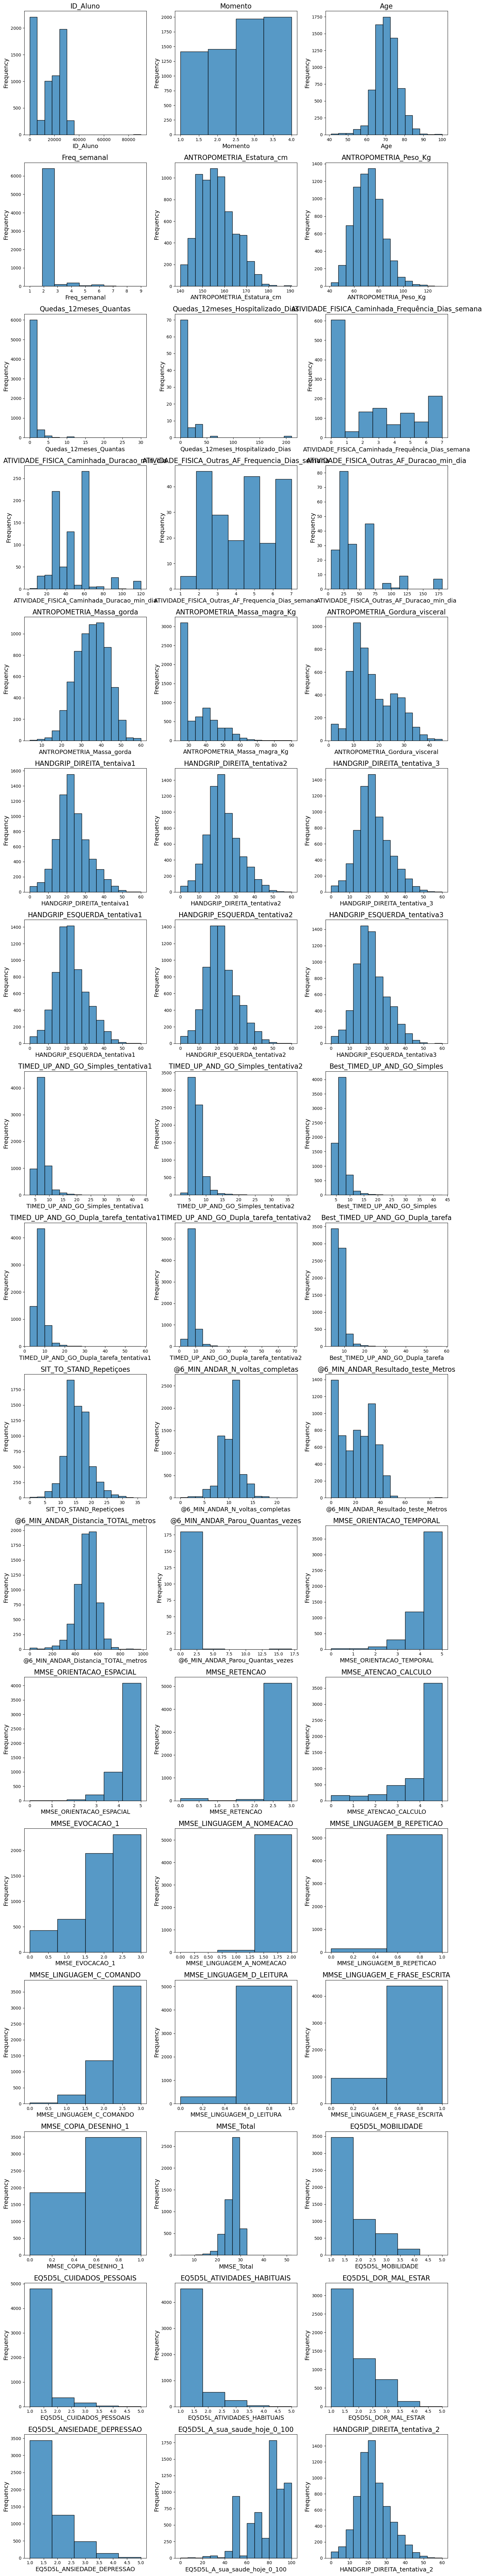

In [23]:
numerical_vars = data.select_dtypes(include='number').columns.tolist()
numerical_vars = [var for var in numerical_vars if len(data[var].unique()) > 2]
ncols = 3

# Calculate the number of rows needed based on the number of columns
nrows = -(-len(numerical_vars) // ncols) 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

# Loop through variables and create histograms
for i, variable in enumerate(numerical_vars):
    ax = axes[i]
    bins = min([len(data[variable].value_counts()),15])
    sns.histplot(data = data, x = variable, ax=ax, bins = bins)
    ax.set_title(variable, fontsize=16) 
    ax.set_xlabel(variable, fontsize=14) 
    ax.set_ylabel('Frequency', fontsize=14)

for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

now all distributions are fixed with no outliers.

In [24]:
data.to_csv("../data/interim/03. FRAIL_clean_numeric.csv", index=False)